# Detecting Contestation — Offline Benchmark (Notebook 06)

A fully **offline** benchmark for Section 5 (no API). It uses the **reconciled
gold** (`feasibility_review_sample_GOLD.csv`, 49 contestation / 39 not) and asks
one honest, tractable question given the sample size:

> **Presence detection** — given a lexically flagged candidate episode, can a model
> reproduce the human's `contestation = yes/no`?

Design choices that keep it defensible on 88 episodes:
- **Participant-level, class-stratified cross-validation** (`StratifiedGroupKFold`
  by transcript), **repeated 5x with different random splits** — no participant
  appears in both train and test, and the reported score is the mean/std across
  repeats, not one lucky split.
- Input for the learned models (TF-IDF, HerBERT, XLM-R) is **context + target**
  (`context_pl` + `text_pl`), matching what the human coders actually read.
  Earlier versions used the target line alone, which under-informed the model
  relative to the humans it was being compared against. The majority-class and
  lexical baselines still use the target line only, since that is how candidates
  were originally flagged.
- The **decision threshold is tuned** per fold via an inner grouped CV *on the
  training data only* (the test fold is never touched), instead of a fixed 0.5
  cutoff.
- HerBERT/XLM-R embeddings are **fused with the lexical hit-count features**
  (`challenge_hits`, `incomprehension_hits`) before the logistic-regression head.
- Models range from a majority-class floor to Polish/multilingual encoders used as
  **frozen feature extractors** (no fine-tuning — 88 examples is far too few to
  fine-tune).

The four structured dimensions (target/grounds/act/response) are **not** benchmarked
— a few examples per class — they are reported descriptively in Notebook 04.

In [1]:
# ============================================================
# 1. Config, load reconciled gold, build X / y / groups
# ============================================================
from __future__ import annotations
import json, logging, warnings
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
LOGGER = logging.getLogger("xai_contestation")

def find_project_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for c in [start, *start.parents]:
        if (c / "data").is_dir(): return c
    raise FileNotFoundError("project root not found")
ROOT = find_project_root()
TABLES = ROOT / "outputs" / "02_translation_and_feasibility_audit" / "tables"
OUT = ROOT / "outputs" / "06_detection_benchmark"; (OUT / "figures").mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
N_SPLITS = 5         # outer, participant-grouped folds
N_REPEATS = 5         # independent reshuffles of the outer CV (different seeds)
INNER_SPLITS = 3      # inner folds used only to pick a decision threshold, on TRAIN data
# Polish + multilingual encoders used as frozen feature extractors.
HERBERT = "allegro/herbert-base-cased"
XLMR = "xlm-roberta-base"
# Purpose-built multilingual sentence-embedding models. Unlike HerBERT/XLM-R above
# (raw mean-pooled hidden states from a masked-LM, never trained to be a good
# *sentence* vector), these are contrastively/paraphrase-trained to be linearly
# useful for exactly this frozen-embedding + linear-head setup.
MPNET = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
E5_BASE = "intfloat/multilingual-e5-base"

# feasibility_review_sample_GOLD.csv is written by Notebook 05, which now also
# excludes interviewer-speaker candidates (out of scope per Sec. 3.2) before
# reconciliation -- so this benchmark automatically runs on the corrected,
# participant-only gold (76 episodes / 46 positive), no filtering needed here.
gold = pd.read_csv(TABLES / "feasibility_review_sample_GOLD.csv")
# merge lexical-signal features (challenge/incomprehension hits) by episode id
sig = pd.read_csv(TABLES / "feasibility_review_sample.csv")[
    ["__utt_id", "challenge_hits", "incomprehension_hits"]]
df = gold.merge(sig, on="__utt_id", how="left")

df = df[df["is_contestation"].astype(str).str.lower().isin(["yes", "no"])].reset_index(drop=True)
y = (df["is_contestation"].astype(str).str.lower() == "yes").astype(int).values

# Target-line-only text -- what the lexical rule / majority floor use (matches how
# candidates were originally flagged).
texts = df["text_pl"].fillna("").astype(str).values

# Context text -- the annotators coded WITH the surrounding turns (context_pl), not
# the target line alone. Most reliability disagreements (10/14 adjudicated cases)
# were "implicit/hidden contestation" legible only from context. Give the learned
# models (TF-IDF, HerBERT, XLM-R, ...) the same information the human coders had.
#
# context_pl is built (Notebook 02) as a running "||"-joined window that already
# INCLUDES the target line in its place in the sequence -- confirmed for all 76
# rows (target text is a substring of context_pl for every episode). An earlier
# version of this cell re-appended text_pl after context_pl, duplicating the
# target inside its own model input. Fixed: use context_pl as-is.
texts_ctx = df["context_pl"].fillna("").astype(str).str.strip().values

# participant/transcript id is the prefix of __utt_id ("PK_DE_01:207" -> "PK_DE_01")
groups = df["__utt_id"].astype(str).str.rsplit(":", n=1).str[0].values

print(f"episodes: {len(df)} | positives(yes)={int(y.sum())} negatives(no)={int((1 - y).sum())}")
print(f"participants (groups): {pd.Series(groups).nunique()} | outer folds: {N_SPLITS} x {N_REPEATS} repeats")
print(f"median context+target length: {int(np.median([len(t) for t in texts_ctx]))} chars "
      f"(target-only median: {int(np.median([len(t) for t in texts]))} chars)")

episodes: 76 | positives(yes)=44 negatives(no)=32
participants (groups): 30 | outer folds: 5 x 5 repeats
median context+target length: 1331 chars (target-only median: 200 chars)


In [2]:
# ============================================================
# 2. Cross-validation helper: repeated, participant-grouped,
#    class-stratified CV, with optional inner-CV threshold tuning
# ============================================================
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score

THRESH_GRID = np.linspace(0.30, 0.70, 9)

def _index(X, idx):
    return [X[i] for i in idx] if isinstance(X, list) else X[idx]

def _select_threshold(y_true, probs, grid=THRESH_GRID):
    # Grid-search the macro-F1-optimal decision threshold.
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        f1 = f1_score(y_true, (probs >= t).astype(int), average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

def _fit_predict(make_model, Xtr, ytr, Xte, groups_tr, seed, tune_threshold):
    # Fit on the outer-train fold. If tune_threshold, pick a decision threshold
    # via an INNER grouped CV run on the training fold only -- the outer test
    # fold is never used to choose the threshold.
    model = make_model()
    model.fit(Xtr, ytr)
    if not (tune_threshold and hasattr(model, "predict_proba")):
        return model.predict(Xte), None
    thresh = 0.5
    try:
        min_class = min(np.bincount(ytr))
        n_inner = min(INNER_SPLITS, int(min_class), pd.Series(groups_tr).nunique())
        if n_inner >= 2:
            inner_cv = StratifiedGroupKFold(n_splits=n_inner, shuffle=True, random_state=seed)
            oof = cross_val_predict(make_model(), Xtr, ytr, groups=groups_tr,
                                     cv=inner_cv, method="predict_proba")[:, 1]
            thresh = _select_threshold(ytr, oof)
    except Exception as error:  # noqa: BLE001 -- never let threshold tuning crash a fold
        LOGGER.debug("threshold tuning skipped (%s)", error)
    probs_te = model.predict_proba(Xte)[:, 1]
    return (probs_te >= thresh).astype(int), thresh

def cv_macro_f1(make_model, X, y, groups, n_splits=N_SPLITS, n_repeats=N_REPEATS,
                 tune_threshold=False):
    # Repeated (n_repeats), participant-grouped, class-stratified CV. Returns
    # mean +/- std of the PER-REPEAT macro-F1 -- i.e. how much the score moves
    # when the train/test split is reshuffled, not just fold-to-fold noise within
    # a single split.
    repeat_f1, repeat_acc, thresholds = [], [], []
    for seed in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        fold_f1, fold_acc = [], []
        for tr, te in sgkf.split(X, y, groups):
            Xtr, Xte = _index(X, tr), _index(X, te)
            pred, thresh = _fit_predict(make_model, Xtr, y[tr], Xte, groups[tr], seed, tune_threshold)
            if thresh is not None:
                thresholds.append(thresh)
            fold_f1.append(f1_score(y[te], pred, average="macro", zero_division=0))
            fold_acc.append(accuracy_score(y[te], pred))
        repeat_f1.append(float(np.mean(fold_f1)))
        repeat_acc.append(float(np.mean(fold_acc)))
    out = {"macro_F1": float(np.mean(repeat_f1)), "macro_F1_std": float(np.std(repeat_f1)),
           "accuracy": float(np.mean(repeat_acc)), "n_repeats": n_repeats}
    if thresholds:
        out["mean_threshold"] = float(np.mean(thresholds))
    return out

results = []

# --- Majority-class floor (no probability threshold to tune) ---
r = cv_macro_f1(lambda: DummyClassifier(strategy="most_frequent"), texts, y, groups)
results.append({"model": "Majority class", "input": "-", **r})

# --- Lexical rule (fixed, deterministic): predict yes if challenge_hits >= 2 ---
# No free parameters, so evaluated directly on the full sample (not CV'd).
lex_pred = (df["challenge_hits"].fillna(0).values >= 2).astype(int)
results.append({"model": "Lexical rule (challenge>=2)", "input": "target line",
                 "macro_F1": f1_score(y, lex_pred, average="macro", zero_division=0),
                 "macro_F1_std": 0.0, "accuracy": accuracy_score(y, lex_pred), "n_repeats": 1})

# --- TF-IDF (word 1-2 grams) + logistic regression, tuned threshold, WITH context ---
def tfidf_model():
    return make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LogisticRegression(max_iter=1000, class_weight="balanced"))
r = cv_macro_f1(tfidf_model, list(texts_ctx), y, groups, tune_threshold=True)
results.append({"model": "TF-IDF + logistic", "input": "context + target", **r})

for row in results:
    thr = f" thr={row.get('mean_threshold', 0.5):.2f}" if "mean_threshold" in row else ""
    print(f"{row['model']:<30} macroF1={row['macro_F1']:.3f} +/- {row['macro_F1_std']:.3f} "
          f"acc={row['accuracy']:.3f}{thr}  [{row['input']}]")

Majority class                 macroF1=0.366 +/- 0.001 acc=0.579  [-]
Lexical rule (challenge>=2)    macroF1=0.481 +/- 0.000 acc=0.513  [target line]
TF-IDF + logistic              macroF1=0.562 +/- 0.027 acc=0.594 thr=0.50  [context + target]


In [3]:
# ============================================================
# 3. Frozen encoder embeddings (HerBERT, XLM-R, mpnet, E5) + logistic,
#    fused with lexical hit-count features, tuned threshold
# ============================================================
def embed(text_list, model_name, batch=16, max_len=256, prefix=""):
    # Mean-pooled last-hidden-state embeddings; downloads the model once.
    # truncation_side="left": when context+target exceeds max_len, tokens are
    # dropped from the START of the context, not from the target line at the end.
    # prefix: some sentence-embedding models (e.g. E5) expect a "query: "/"passage: "
    # prefix on every input; ignored ("") for plain encoders (HerBERT, XLM-R).
    # Output is L2-normalized -- standard practice for sentence-embedding models and
    # harmless for the raw encoders, since StandardScaler follows downstream anyway.
    import torch
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(model_name)
    tok.truncation_side = "left"
    mdl = AutoModel.from_pretrained(model_name).eval()
    dev = "cuda" if torch.cuda.is_available() else "cpu"; mdl.to(dev)
    vecs = []
    with torch.no_grad():
        for i in range(0, len(text_list), batch):
            b = [prefix + t for t in text_list[i:i + batch]] if prefix else list(text_list[i:i + batch])
            enc = tok(b, return_tensors="pt", padding=True, truncation=True,
                      max_length=max_len).to(dev)
            h = mdl(**enc).last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1)
            emb = (h * mask).sum(1) / mask.sum(1).clamp(min=1)
            vecs.append(emb.cpu().numpy())
    vecs = np.vstack(vecs)
    return vecs / np.clip(np.linalg.norm(vecs, axis=1, keepdims=True), 1e-9, None)

from sklearn.preprocessing import StandardScaler

def lr_scaled():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))

# Fuse the frozen embedding with the two lexical hit-count features used by the
# rule-based baseline, so the classifier sees both signal types.
lex_feats = df[["challenge_hits", "incomprehension_hits"]].fillna(0).to_numpy(dtype=float)

# Cache every encoder's fused embeddings (not just one) so cell 5's error
# analysis can select whichever model actually comes out on top in cell 4,
# instead of assuming in advance which one that will be.
ENCODER_EMB = {}
try:
    for label, name, prefix in [("HerBERT (PL) + logistic", HERBERT, ""),
                                ("XLM-R (multi) + logistic", XLMR, ""),
                                ("mpnet-paraphrase (multi) + logistic", MPNET, ""),
                                ("multilingual-E5-base + logistic", E5_BASE, "query: ")]:
        LOGGER.info("embedding with %s ...", name)
        Xe = embed(list(texts_ctx), name, prefix=prefix)
        Xe_fused = np.hstack([Xe, lex_feats])
        r = cv_macro_f1(lr_scaled, Xe_fused, y, groups, tune_threshold=True)
        results.append({"model": label, "input": "context + target + lexical feats", **r})
        thr = f" thr={r.get('mean_threshold', 0.5):.2f}" if "mean_threshold" in r else ""
        print(f"{label:<30} macroF1={r['macro_F1']:.3f} +/- {r['macro_F1_std']:.3f}{thr}")
        ENCODER_EMB[label] = Xe_fused.copy()
        if name == XLMR:  # keep XLM-R's embeddings around specifically for the ensemble cell
            XLMR_EMB = Xe_fused.copy()
except Exception as error:  # noqa: BLE001
    LOGGER.warning("Encoder step skipped (%s). Install transformers/torch to enable.", error)

INFO | embedding with allegro/herbert-base-cased ...


INFO | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"


INFO | HTTP Request: HEAD https://huggingface.co/allegro/herbert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allegro/herbert-base-cased/50e33e0567be0c0b313832314c586e3df0dc2297/config.json "HTTP/1.1 200 OK"


INFO | HTTP Request: HEAD https://huggingface.co/allegro/herbert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"


...

INFO | HTTP Request: HEAD https://huggingface.co/intfloat/multilingual-e5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/intfloat/multilingual-e5-base/d128750597153bb5987e10b1c3493a34e5a4502a/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8211.26it/s]

multilingual-E5-base + logistic macroF1=0.566 +/- 0.020 thr=0.48


In [4]:
# ============================================================
# 3b. Two-signal ensemble: TF-IDF (explicit lexical markers) +
#     XLM-R (best semantic encoder), probability-averaged. The
#     threshold is tuned on the AVERAGED inner-CV out-of-fold
#     probabilities, on the training fold only.
# ============================================================
def _ensemble_cv(text_X, emb_X, y, groups, n_splits=N_SPLITS, n_repeats=N_REPEATS):
    repeat_f1, repeat_acc, thresholds = [], [], []
    for seed in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        fold_f1, fold_acc = [], []
        for tr, te in sgkf.split(emb_X, y, groups):
            Xtr_txt = [text_X[i] for i in tr]; Xte_txt = [text_X[i] for i in te]
            Xtr_emb, Xte_emb = emb_X[tr], emb_X[te]
            ytr, yte, gtr = y[tr], y[te], groups[tr]

            m_txt = tfidf_model(); m_txt.fit(Xtr_txt, ytr)
            m_emb = lr_scaled(); m_emb.fit(Xtr_emb, ytr)

            thresh = 0.5
            try:
                min_class = min(np.bincount(ytr))
                n_inner = min(INNER_SPLITS, int(min_class), pd.Series(gtr).nunique())
                if n_inner >= 2:
                    inner_cv = StratifiedGroupKFold(n_splits=n_inner, shuffle=True, random_state=seed)
                    oof_txt = cross_val_predict(tfidf_model(), Xtr_txt, ytr, groups=gtr,
                                                 cv=inner_cv, method="predict_proba")[:, 1]
                    oof_emb = cross_val_predict(lr_scaled(), Xtr_emb, ytr, groups=gtr,
                                                 cv=inner_cv, method="predict_proba")[:, 1]
                    thresh = _select_threshold(ytr, (oof_txt + oof_emb) / 2)
            except Exception as error:  # noqa: BLE001
                LOGGER.debug("ensemble threshold tuning skipped (%s)", error)

            probs = (m_txt.predict_proba(Xte_txt)[:, 1] + m_emb.predict_proba(Xte_emb)[:, 1]) / 2
            pred = (probs >= thresh).astype(int)
            fold_f1.append(f1_score(yte, pred, average="macro", zero_division=0))
            fold_acc.append(accuracy_score(yte, pred))
            thresholds.append(thresh)
        repeat_f1.append(float(np.mean(fold_f1))); repeat_acc.append(float(np.mean(fold_acc)))
    return {"macro_F1": float(np.mean(repeat_f1)), "macro_F1_std": float(np.std(repeat_f1)),
            "accuracy": float(np.mean(repeat_acc)), "n_repeats": n_repeats,
            "mean_threshold": float(np.mean(thresholds))}

if "XLMR_EMB" in dir():
    r = _ensemble_cv(list(texts_ctx), XLMR_EMB, y, groups)
    results.append({"model": "Ensemble: TF-IDF + XLM-R (avg prob)",
                     "input": "context + target (+lexical feats on the XLM-R half)", **r})
    print(f"Ensemble (TF-IDF + XLM-R)      macroF1={r['macro_F1']:.3f} +/- {r['macro_F1_std']:.3f} "
          f"thr={r['mean_threshold']:.2f}")
else:
    LOGGER.warning("XLM-R embeddings not captured -- run cell 3 first.")

Ensemble (TF-IDF + XLM-R)      macroF1=0.594 +/- 0.023 thr=0.56


,model,input,macro_F1,macro_F1_std,accuracy,n_repeats,mean_threshold
0,Majority class,-,0.366,0.001,0.579,5,NaN
1,Lexical rule (challenge>=2),target line,0.481,0.000,0.513,1,NaN
2,mpnet-paraphrase (multi) + logistic,context + target + lexical feats,0.518,0.015,0.541,5,0.506
3,HerBERT (PL) + logistic,context + target + lexical feats,0.554,0.045,0.593,5,0.552
4,TF-IDF + logistic,context + target,0.562,0.027,0.594,5,0.500
5,multilingual-E5-base + logistic,context + target + lexical feats,0.566,0.020,0.582,5,0.480
6,XLM-R (multi) + logistic,context + target + lexical feats,0.572,0.020,0.603,5,0.522
7,Ensemble: TF-IDF + XLM-R (avg prob),context + target (+lexical feats on the XLM-R ...,0.594,0.023,0.620,5,0.558


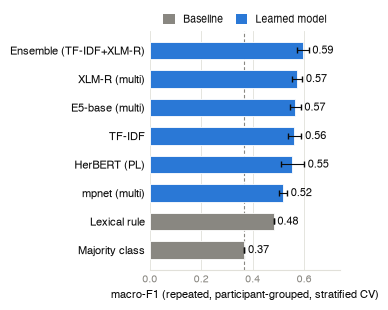


wrote benchmark_presence.csv + benchmark_summary.json


In [5]:
# ============================================================
# 4. Benchmark table + figure
# ============================================================
cols = ["model", "input", "macro_F1", "macro_F1_std", "accuracy", "n_repeats", "mean_threshold"]
bench = pd.DataFrame(results).reindex(columns=cols).round(3)  # mean_threshold is NaN where not tuned
bench = bench.sort_values("macro_F1").reset_index(drop=True)
display(bench)
bench.to_csv(OUT / "benchmark_presence.csv", index=False)

BASELINE_MODELS = {"Majority class", "Lexical rule (challenge>=2)"}
short_name = {
    "Majority class": "Majority class", "Lexical rule (challenge>=2)": "Lexical rule",
    "mpnet-paraphrase (multi) + logistic": "mpnet (multi)",
    "multilingual-E5-base + logistic": "E5-base (multi)",
    "HerBERT (PL) + logistic": "HerBERT (PL)", "TF-IDF + logistic": "TF-IDF",
    "Ensemble: TF-IDF + XLM-R (avg prob)": "Ensemble (TF-IDF+XLM-R)",
    "XLM-R (multi) + logistic": "XLM-R (multi)",
}
try:
    import matplotlib.pyplot as plt
    BLUE, GRAY, INK, GRID = "#2a78d6", "#898781", "#0b0b0b", "#e1e0d9"
    plt.rcParams.update({
        "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
        "xtick.color": GRAY, "ytick.color": INK, "font.size": 9,
    })
    plot_df = bench.sort_values("macro_F1", ascending=True).reset_index(drop=True)
    labels = [short_name.get(m, m) for m in plot_df["model"]]
    colors = [GRAY if m in BASELINE_MODELS else BLUE for m in plot_df["model"]]
    floor = bench.loc[bench["model"] == "Majority class", "macro_F1"].iloc[0]

    fig, ax = plt.subplots(figsize=(3.4, 3.0))
    ypos = range(len(plot_df))  # NB: don't call this `y` -- shadows the global label array
    ax.barh(ypos, plot_df["macro_F1"], height=0.62, color=colors, edgecolor="white",
            linewidth=0.6, zorder=3,
            xerr=plot_df["macro_F1_std"].fillna(0),
            error_kw={"ecolor": INK, "elinewidth": 0.8, "capsize": 2, "zorder": 4})
    for yi, (v, s) in enumerate(zip(plot_df["macro_F1"], plot_df["macro_F1_std"].fillna(0))):
        ax.text(v + s + 0.015, yi, f"{v:.2f}", va="center", ha="left", fontsize=7.8, color=INK)
    ax.axvline(floor, color=GRAY, linewidth=0.8, linestyle=(0, (3, 2)), zorder=2)
    ax.set_yticks(list(ypos)); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(0, plot_df["macro_F1"].max() + plot_df["macro_F1_std"].fillna(0).max() + 0.10)
    ax.set_xlabel("macro-F1 (repeated, participant-grouped, stratified CV)", fontsize=8)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(axis="y", length=0); ax.tick_params(axis="x", length=0, labelsize=7.5)
    ax.xaxis.grid(True, color=GRID, linewidth=0.6, zorder=0); ax.set_axisbelow(True)

    from matplotlib.patches import Patch
    leg = ax.legend(handles=[Patch(facecolor=GRAY, label="Baseline"),
                             Patch(facecolor=BLUE, label="Learned model")],
                    loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2,
                    frameon=False, fontsize=7.5, handlelength=1.1, handleheight=1.1,
                    columnspacing=1.2, borderaxespad=0.2)

    fig.tight_layout(pad=0.4)
    fig.savefig(OUT / "figures" / "benchmark_presence.pdf", bbox_inches="tight",
                bbox_extra_artists=(leg,))
    fig.savefig(OUT / "figures" / "benchmark_presence.png", dpi=300, bbox_inches="tight",
                bbox_extra_artists=(leg,))
    plt.show()
except Exception as error:  # noqa: BLE001
    LOGGER.warning("figure skipped (%s)", error)

(OUT / "benchmark_summary.json").write_text(json.dumps({
    "task": "presence detection (contestation yes/no) on lexically flagged candidates",
    "gold": "feasibility_review_sample_GOLD.csv",
    "n_episodes": int(len(df)), "n_positive": int(y.sum()),
    "cv": f"StratifiedGroupKFold({N_SPLITS}) by participant, repeated {N_REPEATS}x with different "
          f"seeds; macro-F1 mean/std reported across the {N_REPEATS} repeat-level means",
    "input": {
        "Majority class / Lexical rule": "target utterance only (text_pl)",
        "TF-IDF + HerBERT + XLM-R + mpnet + E5": "context turns including the target utterance "
                                                    "in place (context_pl); truncation drops from "
                                                    "the start of context, not the target",
    },
    "threshold_tuning": f"inner StratifiedGroupKFold ({INNER_SPLITS}-fold) on the training fold "
                         f"only; grid-searched over {THRESH_GRID.tolist()}",
    "lexical_feature_fusion": "all four frozen-encoder embeddings (HerBERT, XLM-R, mpnet-paraphrase, "
                               "multilingual-E5) concatenated with challenge_hits/incomprehension_hits "
                               "before logistic regression; TF-IDF and the ensemble's TF-IDF half do "
                               "not receive these features",
    "results": bench.to_dict(orient="records"),
}, indent=2))
print("\nwrote benchmark_presence.csv + benchmark_summary.json")

## What this feeds and its limits

- The table → Table `tab:benchmark` (presence task). Report **macro-F1 mean ± std
  across repeats** under repeated, participant-grouped, stratified CV; state
  plainly that trained models are compared against a majority floor and a lexical
  rule.
- **Scope, stated up front:** one task (presence), 88 episodes, frozen encoders (no
  fine-tuning — too few examples). This is a *feasibility* benchmark, not a full
  four-task system — say so.
- **Context is now in the loop.** TF-IDF/HerBERT/XLM-R see `context_pl + text_pl`,
  the same window the human coders used; the majority/lexical baselines still see
  the target line only. Whether this closes the gap on the *implicit* cases the
  reliability analysis flagged as hardest is the error-analysis story for
  Section 5.4 — pull specific examples from the reconciled gold.
- Adding an **LLM (zero/few-shot) row** later (Notebook 03 with a real API key) slots
  straight into this table.

Re-running top-to-bottom regenerates every number from the reconciled gold. The
encoder cell downloads HerBERT (~0.5 GB) and XLM-R (~1.1 GB) once (cached after
first run).

In [6]:
# ============================================================
# 5. Error analysis: does the best-performing model miss IMPLICIT
#    contestation more than explicit? (claimed in Sec. 3 of the paper --
#    verify it here rather than assert it.) "Best" is determined from
#    the actual results table, not assumed in advance -- whichever of
#    the four frozen encoders scored highest in cell 3/4 is the one
#    analyzed here.
# ============================================================
best_label = max(
    (r for r in results if r["model"] in ENCODER_EMB),
    key=lambda r: r["macro_F1"],
)["model"]
BEST_EMB = ENCODER_EMB[best_label]
print(f"error analysis run on: {best_label} (highest macro-F1 among the frozen encoders)")

miss = np.zeros(len(df)); seen = np.zeros(len(df))
for seed in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for tr, te in sgkf.split(BEST_EMB, y, groups):
        pred, _ = _fit_predict(lr_scaled, BEST_EMB[tr], y[tr], BEST_EMB[te], groups[tr], seed, True)
        seen[te] += 1
        miss[te] += (pred != y[te]).astype(int)

df["_error_rate"] = miss / np.clip(seen, 1, None)  # fraction of repeats the best model got this episode wrong

# False-negative rate among CONFIRMED contestation episodes, by presence subtype
# (this is the claim to check: implicit episodes missed more often than explicit)
yes_mask = (y == 1)
err_yes = pd.DataFrame({"presence": df.loc[yes_mask, "presence"].values,
                        "target": df.loc[yes_mask, "target"].values,
                        "fn_rate": df.loc[yes_mask, "_error_rate"].values})
by_presence = err_yes.groupby("presence")["fn_rate"].agg(["mean", "count"]).round(3)
by_presence.columns = ["mean_false_negative_rate", "n_episodes"]
print(f"\nFalse-negative rate ({best_label}), by presence subtype, among the {int(y.sum())} confirmed-contestation episodes:")
display(by_presence.sort_values("mean_false_negative_rate", ascending=False))

by_target = err_yes.groupby("target")["fn_rate"].agg(["mean", "count"]).round(3)
by_target.columns = ["mean_false_negative_rate", "n_episodes"]
print(f"\nFalse-negative rate ({best_label}), by target, among the {int(y.sum())} confirmed-contestation episodes:")
display(by_target.sort_values("mean_false_negative_rate", ascending=False))

# False-positive rate among confirmed non-contestation episodes (for completeness)
no_mask = (y == 0)
fp_rate = df.loc[no_mask, "_error_rate"].mean()
print(f"\noverall false-positive rate ({best_label}) on the {int((1 - y).sum())} non-contestation episodes: {fp_rate:.3f}")

by_presence.to_csv(OUT / "error_by_presence.csv")
by_target.to_csv(OUT / "error_by_target.csv")
print("\nwrote error_by_presence.csv + error_by_target.csv")

error analysis run on: XLM-R (multi) + logistic (highest macro-F1 among the frozen encoders)



False-negative rate (XLM-R (multi) + logistic), by presence subtype, among the 44 confirmed-contestation episodes:


,mean_false_negative_rate,n_episodes
presence,,
ambiguous,0.446,13
explicit,0.275,16
implicit,0.227,15



False-negative rate (XLM-R (multi) + logistic), by target, among the 44 confirmed-contestation episodes:


,mean_false_negative_rate,n_episodes
target,,
system competence,0.750,4
reasoning,0.500,6
evidence,0.375,8
input data,0.286,7
prediction,0.200,3
explanation representation,0.125,16



overall false-positive rate (XLM-R (multi) + logistic) on the 32 non-contestation episodes: 0.519

wrote error_by_presence.csv + error_by_target.csv
